In [1]:
from calculate_mde import *
from matplotlib import pyplot as plt

In [11]:
def draw_mde_curve(mdes_dataframe, metric, num_iterations, type = 'rel'):
    for index, row in mdes_dataframe.iterrows():
        if type == 'rel':
            columns = [f"{metric}_{i}_mde_rel" for i in range(1, num_iterations + 1)]
        elif type == 'abs':
            columns = [f"{metric}_{i}_mde" for i in range(1, num_iterations + 1)]
        values = row[columns]
        
        plt.plot(
            [i+1 for i in range(num_iterations)],
            values,
            label = index
        )
    plt.legend()
    plt.xlabel('num_iterations')
    plt.ylabel('mde')
    

def draw_time_iter_curve(mdes_dataframe, num_iterations):
    for index, row in mdes_dataframe.iterrows():
        values = row['_runtime_mean'].values[0] / 60
        plt.plot(
            [i+1 for i in range(num_iterations)],
            [values * (i+1) for i in range(num_iterations)],
            label = index
        )
    plt.legend()
    plt.xlabel('num_iterations')
    plt.ylabel('runtime, minutes')
    

In [3]:
metrics = ['80_nmi', '80_roc_auc']
grouping_keys = ['exp_id', 'approach__name', 'feature_extractor__name']
epoch = 145

prepeared_data = prepare_data_from_wandb(epoch = epoch, metrics = metrics, grouping_keys = grouping_keys)

In [4]:
prepeared_data.head()

,80_nmi,80_roc_auc,_runtime,exp_id,approach__name,feature_extractor__name
0,0.573108,0.981732,1364.651109,DC,Deep Clustering,ResNet_1D
1,0.542992,0.983371,1342.883475,DC,Deep Clustering,ResNet_1D
2,0.546718,0.990129,1307.926601,DC,Deep Clustering,ResNet_1D
3,0.499441,0.972395,1355.438036,DC,Deep Clustering,ResNet_1D
4,0.540643,0.997219,1349.367725,DC,Deep Clustering,ResNet_1D


In [5]:
calculate_mde_from_runs(prepeared_data, grouping_keys, num_iterations=1)

80_nmi_1_mde  80_nmi_1_mean  \
exp_id approach__name  feature_extractor__name                                  
AE     AE              AE_CNN_1D               0      0.009738       0.577817   
                       AE_KAN                  0      0.009141       0.585306   
CL     Sim_CLR         KANS_Encoder            0      0.008338       0.555654   
                       ResNet_1D               0      0.009840       0.557772   
DC     Deep Clustering KANS_Encoder            0      0.011903       0.543416   
                       ResNet_1D               0      0.014827       0.542949   
                       Simple_CNN_1D           0      0.016305       0.526877   

                                                  80_nmi_1_mde_rel  \
exp_id approach__name  feature_extractor__name                       
AE     AE              AE_CNN_1D               0          1.685250   
                       AE_KAN                  0          1.561745   
CL     Sim_CLR         KANS_Encoder            0          1.500569   
                       ResNet_1D               0          1.764134   
DC     Deep Clustering KANS_Encoder            0          2.190348   
                       ResNet_1D               0          2.730883   
                       Simple_CNN_1D           0          3.094623   

                                                  80_roc_auc_1_mde  \
exp_id approach__name  feature_extractor__name                       
AE     AE              AE_CNN_1D               0          0.016304   
                       AE_KAN                  0          0.027268   
CL     Sim_CLR         KANS_Encoder            0          0.029947   
                       ResNet_1D               0          0.057603   
DC     Deep Clustering KANS_Encoder            0          0.036504   
                       ResNet_1D               0          0.036454   
                       Simple_CNN_1D           0          0.043714   

                                                  80_roc_auc_1_mean  \
exp_id approach__name  feature_extractor__name                        
AE     AE              AE_CNN_1D               0           0.981113   
                       AE_KAN                  0           0.969862   
CL     Sim_CLR         KANS_Encoder            0           0.953689   
                       ResNet_1D               0           0.875778   
DC     Deep Clustering KANS_Encoder            0           0.941228   
                       ResNet_1D               0           0.953382   
                       Simple_CNN_1D           0           0.935347   

                                                  80_roc_auc_1_mde_rel  \
exp_id approach__name  feature_extractor__name                           
AE     AE              AE_CNN_1D               0              1.661779   
                       AE_KAN                  0              2.811485   
CL     Sim_CLR         KANS_Encoder            0              3.140131   
                       ResNet_1D               0              6.577335   
DC     Deep Clustering KANS_Encoder            0              3.878365   
                       ResNet_1D               0              3.823700   
                       Simple_CNN_1D           0              4.673515   

                                                  _runtime_1_mde  \
exp_id approach__name  feature_extractor__name                     
AE     AE              AE_CNN_1D               0       48.828653   
                       AE_KAN                  0       52.959642   
CL     Sim_CLR         KANS_Encoder            0      189.432551   
                       ResNet_1D               0      117.468074   
DC     Deep Clustering KANS_Encoder            0       69.829933   
                       ResNet_1D               0       61.325530   
                       Simple_CNN_1D           0       47.643669   

                                                  _runtime_1_mean  \
exp_id approach__name  feature_extractor__name                      


In [6]:
# What if increase number of iterations
mdes = calculate_mde_from_runs(prepeared_data, grouping_keys, num_iterations=10)

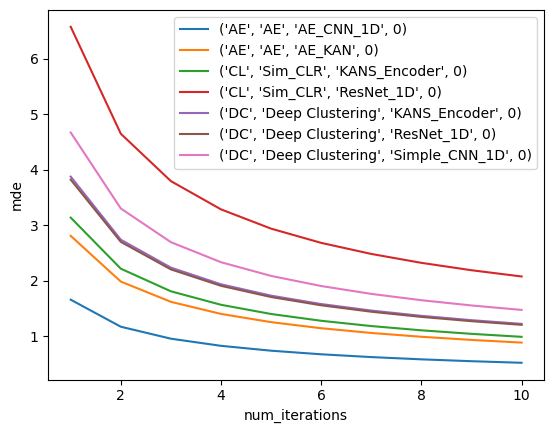

In [7]:
draw_mde_curve(mdes, '80_roc_auc', num_iterations=10)

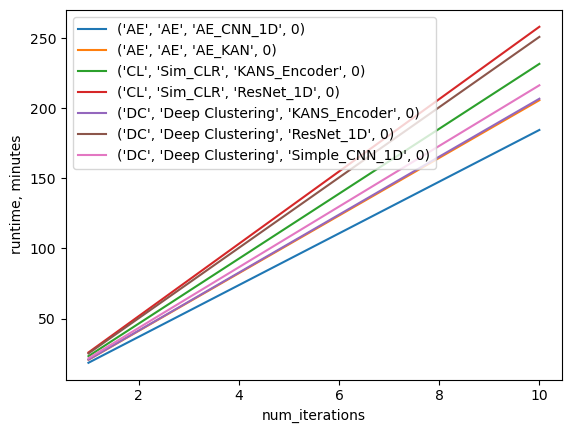

In [12]:
draw_time_iter_curve(mdes, num_iterations=10)

In [26]:
metrics = ['300_nmi', '300_roc_auc']
grouping_keys = ['exp_id', 'approach__name', 'feature_extractor__name']
epoch = 95
project = 'LoRa_evaluations_for_paper_same_days'

prepeared_data = prepare_data_from_wandb(project = project, epoch = epoch, metrics = metrics, grouping_keys = grouping_keys)

In [27]:
calculate_mde_from_runs(prepeared_data, grouping_keys, num_iterations=10).style

,,,,300_nmi_1_mde,300_nmi_1_mean,300_nmi_1_mde_rel,300_roc_auc_1_mde,300_roc_auc_1_mean,300_roc_auc_1_mde_rel,_runtime_1_mde,_runtime_1_mean,_runtime_1_mde_rel,_runtime_mean,300_nmi_2_mde,300_nmi_2_mean,300_nmi_2_mde_rel,300_roc_auc_2_mde,300_roc_auc_2_mean,300_roc_auc_2_mde_rel,_runtime_2_mde,_runtime_2_mean,_runtime_2_mde_rel,_runtime_mean,300_nmi_3_mde,300_nmi_3_mean,300_nmi_3_mde_rel,300_roc_auc_3_mde,300_roc_auc_3_mean,300_roc_auc_3_mde_rel,_runtime_3_mde,_runtime_3_mean,_runtime_3_mde_rel,_runtime_mean,300_nmi_4_mde,300_nmi_4_mean,300_nmi_4_mde_rel,300_roc_auc_4_mde,300_roc_auc_4_mean,300_roc_auc_4_mde_rel,_runtime_4_mde,_runtime_4_mean,_runtime_4_mde_rel,_runtime_mean,300_nmi_5_mde,300_nmi_5_mean,300_nmi_5_mde_rel,300_roc_auc_5_mde,300_roc_auc_5_mean,300_roc_auc_5_mde_rel,_runtime_5_mde,_runtime_5_mean,_runtime_5_mde_rel,_runtime_mean,300_nmi_6_mde,300_nmi_6_mean,300_nmi_6_mde_rel,300_roc_auc_6_mde,300_roc_auc_6_mean,300_roc_auc_6_mde_rel,_runtime_6_mde,_runtime_6_mean,_runtime_6_mde_rel,_runtime_mean,300_nmi_7_mde,300_nmi_7_mean,300_nmi_7_mde_rel,300_roc_auc_7_mde,300_roc_auc_7_mean,300_roc_auc_7_mde_rel,_runtime_7_mde,_runtime_7_mean,_runtime_7_mde_rel,_runtime_mean,300_nmi_8_mde,300_nmi_8_mean,300_nmi_8_mde_rel,300_roc_auc_8_mde,300_roc_auc_8_mean,300_roc_auc_8_mde_rel,_runtime_8_mde,_runtime_8_mean,_runtime_8_mde_rel,_runtime_mean,300_nmi_9_mde,300_nmi_9_mean,300_nmi_9_mde_rel,300_roc_auc_9_mde,300_roc_auc_9_mean,300_roc_auc_9_mde_rel,_runtime_9_mde,_runtime_9_mean,_runtime_9_mde_rel,_runtime_mean,300_nmi_10_mde,300_nmi_10_mean,300_nmi_10_mde_rel,300_roc_auc_10_mde,300_roc_auc_10_mean,300_roc_auc_10_mde_rel,_runtime_10_mde,_runtime_10_mean,_runtime_10_mde_rel,_runtime_mean
exp_id,approach__name,feature_extractor__name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CL,Sim_CLR,ResNet_1D,0,0.023806,0.042928,55.456237,0.078656,0.527219,14.919054,18562.083957,24360.981302,76.195962,24360.981302,0.016833,0.042928,39.213482,0.055618,0.527219,10.549365,13125.375439,24360.981302,53.878681,24360.981302,0.013744,0.042928,32.017674,0.045412,0.527219,8.613520,10716.824169,24360.981302,43.991759,24360.981302,0.011903,0.042928,27.728119,0.039328,0.527219,7.459527,9281.041979,24360.981302,38.097981,24360.981302,0.010646,0.042928,24.800783,0.035176,0.527219,6.672004,8301.216306,24360.981302,34.075870,24360.981302,0.009719,0.042928,22.639914,0.032111,0.527219,6.090678,7577.939043,24360.981302,31.106871,24360.981302,0.008998,0.042928,20.960488,0.029729,0.527219,5.638873,7015.808281,24360.981302,28.799366,24360.981302,0.008417,0.042928,19.606741,0.027809,0.527219,5.274682,6562.687720,24360.981302,26.939341,24360.981302,0.007935,0.042928,18.485412,0.026219,0.527219,4.973018,6187.361319,24360.981302,25.398654,24360.981302,0.007528,0.042928,17.536802,0.024873,0.527219,4.717819,5869.846342,24360.981302,24.095279,24360.981302
DC,Deep Clustering,Simple_CNN_1D,0,0.001753,0.012285,14.268337,0.010680,0.504516,2.116973,271.978350,8492.510913,3.202567,8492.510913,0.001239,0.012285,10.089238,0.007552,0.504516,1.496926,192.317736,8492.510913,2.264557,8492.510913,0.001012,0.012285,8.237828,0.006166,0.504516,1.222235,157.026774,8492.510913,1.849003,8492.510913,0.000876,0.012285,7.134169,0.005340,0.504516,1.058487,135.989175,8492.510913,1.601283,8492.510913,0.000784,0.012285,6.380994,0.004776,0.504516,0.946739,121.632416,8492.510913,1.432231,8492.510913,0.000716,0.012285,5.825024,0.004360,0.504516,0.864251,111.034697,8492.510913,1.307442,8492.510913,0.000663,0.012285,5.392925,0.004037,0.504516,0.800141,102.798154,8492.510913,1.210457,8492.510913,0.000620,0.012285,5.044619,0.003776,0.504516,0.748463,96.158868,8492.510913,1.132278,8492.510913,0.000584,0.012285,4.756112,0.003560,0.504516,0.705658,90.659450,8492.510913,1.067522,8492.510913,0.000554,0.012285,4.512044,0.003377,0.504516,0.669446,86.007106,8492.510913,1.012741,8492.510913


In [28]:
mdes = calculate_mde_from_runs(prepeared_data, grouping_keys, num_iterations=10)

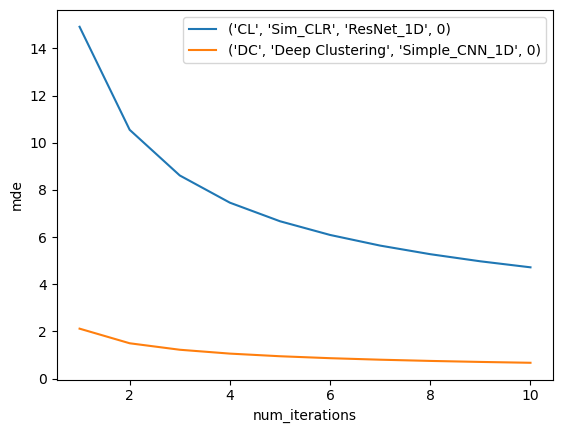

In [30]:
draw_mde_curve(mdes, '300_roc_auc', num_iterations=10)

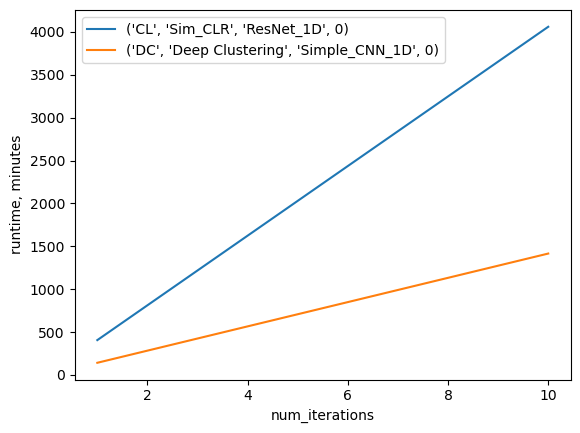

In [31]:
draw_time_iter_curve(mdes, num_iterations=10)